In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [ ]:
import numpy as np
import pennylane as qml
import pubchempy as pcp

def generate_molecule_data(molecule_name="H2", source="qchem", local_dataset_path="./datasets"):
    # Get the time set T
    op_times = np.sort(np.array([-2**k for k in range(1, 5)] + [2**k for k in range(1, 5)]) / 160)

    # Build operator set P for each molecule
    molecule_data = dict()
    
    if source == "qchem":
        try:
            # Try to load locally first or normally if online
            datasets = qml.data.load("qchem", molname=molecule_name, folder_path=local_dataset_path)
        except Exception:
            datasets = qml.data.load("qchem", molname=molecule_name)
            
        dataset = datasets[0]
        molecule = dataset.molecule
        symbols = molecule.symbols
        coords = molecule.coordinates
        num_electrons, num_qubits = molecule.n_electrons, 2 * molecule.n_orbitals
        hf_state = dataset.hf_state
        hamiltonian = dataset.hamiltonian
        expected_ground_state_E = dataset.fci_energy
        
    elif source == "pubchem":
        # Fetch from PubChem
        compounds = pcp.get_compounds(molecule_name, 'name', record_type='3d')
        if not compounds or not hasattr(compounds[0].atoms[0], 'x') or compounds[0].atoms[0].x is None:
            # Fallback to 2D if 3D is not available
            compounds = pcp.get_compounds(molecule_name, 'name')
            
        c = compounds[0]
        symbols = [atom.element for atom in c.atoms]
        # Extract coordinates, defaulting to 0.0 if not present
        coords = np.array([[getattr(atom, 'x', 0.0) or 0.0, 
                            getattr(atom, 'y', 0.0) or 0.0, 
                            getattr(atom, 'z', 0.0) or 0.0] for atom in c.atoms])
        
        # Build Hamiltonian and molecule using PennyLane
        hamiltonian, num_qubits = qml.qchem.molecular_hamiltonian(symbols, coords)
        
        # Simple estimation of electrons (assuming neutral molecule)
        electron_map = {'H': 1, 'C': 6, 'N': 7, 'O': 8, 'F': 9, 'I': 53}
        num_electrons = sum([electron_map.get(s, 0) for s in symbols]) 
        
        hf_state = qml.qchem.hf_state(num_electrons, num_qubits)
        expected_ground_state_E = None # FCI energy isn't directly pulled from PubChem

    singles, doubles = qml.qchem.excitations(num_electrons, num_qubits)
    double_excs = [qml.DoubleExcitation(time, wires=double) for double in doubles for time in op_times]
    single_excs = [qml.SingleExcitation(time, wires=single) for single in singles for time in op_times]
    identity_ops = [qml.exp(qml.I(range(num_qubits)), 1j*time) for time in op_times] # For Identity
    operator_pool = double_excs + single_excs + identity_ops
    
    molecule_data[molecule_name] = {
        "op_pool": np.array(operator_pool), 
        "num_qubits": num_qubits,
        "hf_state": hf_state,
        "hamiltonian": hamiltonian,
        "expected_ground_state_E": expected_ground_state_E,
        "symbols": symbols,
        "geometry": coords,
        "active_electrons": num_electrons,
        "active_orbitals": num_qubits // 2
    }
    
    return molecule_data

In [3]:
target_molecule = "H2O"

# Helper to safely get the length of hamiltonian terms across PL versions
def get_hamiltonian_terms_len(h):
    return len(getattr(h, "ops", getattr(h, "operands", [])))

# 1. Load via qchem
qchem_molecule_data = generate_molecule_data(target_molecule, source="qchem")
qchem_data = qchem_molecule_data[target_molecule]

print(f"--- {target_molecule} (qchem) ---")
print(f"Number of Qubits: {qchem_data['num_qubits']}")
print(f"Operator Pool Size: {len(qchem_data['op_pool'])}")
print(f"HF State: {qchem_data['hf_state']}")
print(f"FCI Energy: {qchem_data['expected_ground_state_E']}")
print(f"Hamiltonian terms: {get_hamiltonian_terms_len(qchem_data['hamiltonian'])}")

# 2. Load via pubchem
pubchem_molecule_data = generate_molecule_data(target_molecule, source="pubchem")
pubchem_data = pubchem_molecule_data[target_molecule]

print(f"\n--- {target_molecule} (pubchem) ---")
print(f"Number of Qubits: {pubchem_data['num_qubits']}")
print(f"Operator Pool Size: {len(pubchem_data['op_pool'])}")
print(f"HF State: {pubchem_data['hf_state']}")
print(f"FCI Energy: {pubchem_data['expected_ground_state_E']}")
print(f"Hamiltonian terms: {get_hamiltonian_terms_len(pubchem_data['hamiltonian'])}")

# Expose standard variables that can be used down the line (defaulting to qchem for now)
op_pool = qchem_data["op_pool"]
num_qubits = qchem_data["num_qubits"]
init_state = qchem_data["hf_state"]
hamiltonian = qchem_data["hamiltonian"]
grd_E = qchem_data["expected_ground_state_E"]
op_pool_size = len(op_pool)

--- H2O (qchem) ---
Number of Qubits: 14
Operator Pool Size: 1128
HF State: [1 1 1 1 1 1 1 1 1 1 0 0 0 0]
FCI Energy: -75.01250626334813
Hamiltonian terms: 1086

--- H2O (pubchem) ---
Number of Qubits: 14
Operator Pool Size: 1128
HF State: [1 1 1 1 1 1 1 1 1 1 0 0 0 0]
FCI Energy: None
Hamiltonian terms: 1558


In [4]:
USE_CUDAQ = False
USE_DIT = False

In [5]:
import pennylane as qml
import numpy as np

if USE_CUDAQ:
    import cudaq

    # 1. Map Hamiltonians
    def pl_hamiltonian_to_cudaq(pl_ham):
        ps = qml.pauli.pauli_sentence(pl_ham)
        cudaq_ham = None
        for pw, coeff in ps.items():
            term = None
            for wire, pauli in pw.items():
                p_op = getattr(cudaq.spin, pauli.lower())(wire)
                term = p_op if term is None else term * p_op
                    
            term = cudaq.spin.i(0) if term is None else term
            cudaq_ham = coeff * term if cudaq_ham is None else cudaq_ham + (coeff * term)
                
        return cudaq_ham

    ham_cudaq = pl_hamiltonian_to_cudaq(hamiltonian)

    # Helper to apply PL ops natively using generators in CUDA-Q
    def apply_pl_op_to_cudaq(kernel, qubits, op):
        if isinstance(op, qml.ops.Exp) and isinstance(op.base, qml.Identity): return
        
        param = op.parameters[0]
        ps = qml.pauli.pauli_sentence(op.generator())
        
        for pw, coeff in ps.items():
            term = None
            for wire, pauli in pw.items():
                p_op = getattr(cudaq.spin, pauli.lower())(wire)
                term = p_op if term is None else term * p_op
                    
            if term is not None:
                kernel.exp_pauli(float(param * coeff), qubits, term)

    # Helper to construct HF state kernel
    def build_base_kernel():
        kernel = cudaq.make_kernel()
        qubits = kernel.qalloc(num_qubits)
        for i, val in enumerate(init_state):
            if val == 1: kernel.x(qubits[i])
        return kernel, qubits

    # 2. Build the GQE CUDA-Q subsequence executor
    def get_subsequence_energies_cudaq(op_seq):
        energies = []
        for ops in op_seq:
            seq_es = []
            for step in range(1, len(ops) + 1):
                kernel, qubits = build_base_kernel()
                for op in ops[:step]:
                    apply_pl_op_to_cudaq(kernel, qubits, op)
                seq_es.append(cudaq.observe(kernel, ham_cudaq).expectation())
            energies.append(seq_es)
            
        return np.array(energies)

    # Verify with a tiny sequence
    print(get_subsequence_energies_cudaq([[op_pool[0], op_pool[1]]]))

In [6]:
dev = qml.device("lightning.qubit", wires=num_qubits)

@qml.qnode(dev)
def energy_circuit(gqe_ops):
    # Computes Eq. 1 from Nakaji et al. based on the selected unitary operators
    qml.BasisState(init_state, wires=range(num_qubits)) # Initial state <-- Hartree Fock state
    for op in gqe_ops:
        qml.Snapshot(measurement=qml.expval(hamiltonian))
        qml.apply(op) # Applies each of the unitary operators
    return qml.expval(hamiltonian)

energy_circuit = qml.snapshots(energy_circuit)

def get_subsequence_energies_pl(op_seq):
    # Collates the energies of each subsequence for a batch of sequences
    energies = []
    for ops in op_seq:
        es = energy_circuit(ops)
        energies.append(
            [es[k].item() for k in list(range(1, len(ops))) + ["execution_results"]]
        )
    return np.array(energies)

def get_subsequence_energies(op_seq):
    if USE_CUDAQ:
        return get_subsequence_energies_cudaq(op_seq)
    else:
        return get_subsequence_energies_pl(op_seq)

if not USE_CUDAQ:
    # Verify with a tiny sequence
    print(get_subsequence_energies([[op_pool[0], op_pool[1]]]))

/Users/nvenkat/anaconda3/envs/qi/lib/python3.13/site-packages/pennylane/debugging/snapshot.py:334: UserWarning: Snapshots are not supported for the given device. Therefore, a tape will be created for each snapshot, resulting in a total of n_snapshots + 1 executions.
  warnings.warn(


[[-74.85023018 -74.71189798]]


In [7]:
# Generate sequence of indices of operators in vocab
import os
train_size = 1024  # Reduced from 1024 -> 512 to speed up dataset generation for larger H2O Hilbert space!
seq_len = 4
trial_name = "trial2_h2o"

# Create the directory structure for saving models and results
save_dir = f"./seq_len={seq_len}/{trial_name}"
os.makedirs(save_dir, exist_ok=True)

train_op_pool_inds = np.random.randint(op_pool_size, size=(train_size, seq_len))

# Corresponding sequence of operators
train_op_seq = op_pool[train_op_pool_inds]

# Corresponding tokens with special starting tokens
train_token_seq = np.concatenate([
    np.zeros(shape=(train_size, 1), dtype=int), # starting token is 0
    train_op_pool_inds + 1 # shift operator inds by one
], axis=1)

# Calculate the energies for each subsequence in the training set
train_sub_seq_en = get_subsequence_energies(train_op_seq)

In [8]:
# !curl -O https://raw.githubusercontent.com/karpathy/nanoGPT/master/model.py
from model import GPT, GPTConfig
import torch
import math
from torch.nn import functional as F
import torch.nn as nn
import math

class GPTQE(GPT):
    def forward(self, idx):
        device = idx.device
        b, t = idx.size()
        pos = torch.arange(0, t, dtype=torch.long, device=device) # shape (t)

        # forward the GPT model itself
        tok_emb = self.transformer.wte(idx) # token embeddings of shape (b, t, n_embd)
        pos_emb = self.transformer.wpe(pos) # position embeddings of shape (t, n_embd)
        x = self.transformer.drop(tok_emb + pos_emb)
        for block in self.transformer.h:
            x = block(x)
        x = self.transformer.ln_f(x)
        logits = self.lm_head(x)
        return logits
    
    def calculate_loss(self, tokens, energies, grd_E=None):
        current_tokens, next_tokens = tokens[:, :-1], tokens[:, 1:]
        # calculate the logits for the next possible tokens in the sequence
        logits = self(current_tokens)
        # get the logit for the actual next token in the sequence
        next_token_mask = torch.nn.functional.one_hot(
            next_tokens, num_classes=self.config.vocab_size
        )
        next_token_logits = (logits * next_token_mask).sum(axis=2)
        # calculate the cumulative logits for each subsequence
        cumsum_logits = torch.cumsum(next_token_logits, dim=1)
        # match cumulative logits to subsequence energies
        loss = torch.mean(torch.square(cumsum_logits - energies))
        if grd_E is not None:
            physical_penalty = torch.mean(torch.relu(grd_E - cumsum_logits)**2)
            loss = loss + 10.0 * physical_penalty
        return loss
    
    @torch.no_grad()
    def generate(self, n_sequences, max_new_tokens, temperature=1.0, device="cpu"):
        idx = torch.zeros(size=(n_sequences, 1), dtype=int, device=device)
        total_logits = torch.zeros(size=(n_sequences, 1), device=device)
        for _ in range(max_new_tokens):
            # if the sequence context is growing too long we must crop it at block_size
            idx_cond = idx if idx.size(1) <= self.config.block_size else idx[:, -self.config.block_size:]
            # forward the model to get the logits for the index in the sequence
            logits = self(idx_cond)
            # pluck the logits at the final step 
            logits = logits[:, -1, :] 
            
            # Since logits predict changes in energy, they might have tiny variance, causing F.softmax(-logits/temperature) 
            # to be completely flat. We standardize the valid logits so the temperature is meaningful and sampling works.
            std, mean = torch.std_mean(logits[:, 1:], dim=-1, keepdim=True)
            logits_scaled = (logits - mean) / (std + 1e-8)
            
            # set the logit of the first token so that its probability will be zero
            logits_scaled[:, 0] = 1e7
            # apply softmax to convert logits to (normalized) probabilities and scale by desired temperature
            probs = F.softmax(-logits_scaled / temperature, dim=-1)
            # Guard against MPS minor negative float inaccuracies or NaNs if diverged
            probs = torch.nan_to_num(probs, nan=1e-10)
            probs = torch.clamp(probs, min=1e-10)
            
            # sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1)
            # Accumulate true unscaled logits for actual energy changes computation
            total_logits += torch.gather(logits, index=idx_next, dim=1)
            # append sampled index to the running sequence and continue
            idx = torch.cat((idx, idx_next), dim=1)
        return idx, total_logits


class MHA(nn.Module):
    """Multi-headed self-attention"""
    def __init__(self, dim: int, heads: int):
        super().__init__()
        assert dim % heads == 0
        self.heads = heads
        self.scale = (dim // heads) ** -0.5
        self.qkv = nn.Linear(dim, dim * 3)
        self.out = nn.Linear(dim, dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        b, n, d = x.shape
        # Compute queries, keys, and values
        qkv = self.qkv(x).chunk(3, dim=-1) # 3 of b n d
        q, k, v = [t.view(b, n, self.heads, d // self.heads).transpose(1, 2) for t in qkv] # b h n d_h

        # Compute attention
        qk = torch.einsum('bhqd,bhkd->bhqk', q, k) * self.scale
        attn = torch.softmax(qk, dim=-1)

        # Combine with values
        out = torch.einsum('bhal,bhld->bhad', attn, v) # b h n d_h
        out = out.transpose(1, 2).reshape(b, n, d)
        
        return self.out(out)


def modulate(x: torch.Tensor, scale: torch.Tensor, bias: torch.Tensor) -> torch.Tensor:
    return x * (1 + scale) + bias


class MLP(nn.Module):
    def __init__(self, in_features: int, hidden_features: int, out_features: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, hidden_features),
            nn.GELU(),
            nn.Linear(hidden_features, out_features)
        )
    def forward(self, x):
        return self.net(x)


class DiffusionTransformerLayer(nn.Module):
    def __init__(self, dim: int, heads: int):
        super().__init__()
        # Normalization
        self.norm1 = nn.RMSNorm(dim, elementwise_affine=False)
        self.norm2 = nn.RMSNorm(dim, elementwise_affine=False)
        self.ada_ln = nn.Sequential(
            nn.RMSNorm(dim, elementwise_affine=False),
            nn.Linear(dim, dim * 6)
        )
        # Initialize conditioning to zero
        nn.init.zeros_(self.ada_ln[1].weight)
        nn.init.zeros_(self.ada_ln[1].bias)
        # Attention
        self.attn = MHA(dim, heads)
        # Feedforward
        self.ff = MLP(dim, 4 * dim, dim)

    def forward(self, x: torch.Tensor, c: torch.Tensor) -> torch.Tensor:
        c = self.ada_ln(c).unsqueeze(1) # b 1 d*6
        attn_scale, attn_bias, attn_gate, ff_scale, ff_bias, ff_gate = c.chunk(6, dim=-1)
        x = x + attn_gate * self.attn(modulate(self.norm1(x), attn_scale, attn_bias))
        x = x + ff_gate * self.ff(modulate(self.norm2(x), ff_scale, ff_bias))
        return x


class DITQE(GPT):
    def __init__(self, config):
        super().__init__(config)
        self.config = config
        
        # DiT specific layers
        self.energy_emb = nn.Sequential(
            nn.Linear(1, config.n_embd),
            nn.GELU(),
            nn.Linear(config.n_embd, config.n_embd)
        )
        
        # Override the transformer layers with DiT layers
        self.transformer.h = nn.ModuleList([
            DiffusionTransformerLayer(dim=config.n_embd, heads=config.n_head)
            for _ in range(config.n_layer)
        ])
        
    def forward(self, idx, energies):
        device = idx.device
        b, t = idx.size()
        pos = torch.arange(0, t, dtype=torch.long, device=device) # shape (t)

        # Forward embeddings
        tok_emb = self.transformer.wte(idx) # token embeddings of shape (b, t, n_embd)
        pos_emb = self.transformer.wpe(pos) # position embeddings of shape (t, n_embd)
        x = self.transformer.drop(tok_emb + pos_emb)
        
        # Conditioning 
        c = self.energy_emb(energies.unsqueeze(-1)) # b n_embd
        
        # Forward DiT blocks
        for block in self.transformer.h:
            x = block(x, c)
            
        x = self.transformer.ln_f(x)
        logits = self.lm_head(x)
        return logits
    
    def calculate_loss(self, tokens, energies, grd_E=None):
        current_tokens, next_tokens = tokens[:, :-1], tokens[:, 1:]
        # pass in the final target energies as conditioning to the model
        logits = self(current_tokens, energies[:, -1])
        next_token_mask = torch.nn.functional.one_hot(
            next_tokens, num_classes=self.config.vocab_size
        )
        next_token_logits = (logits * next_token_mask).sum(axis=2)
        cumsum_logits = torch.cumsum(next_token_logits, dim=1)
        loss = torch.mean(torch.square(cumsum_logits - energies))
        if grd_E is not None:
            physical_penalty = torch.mean(torch.relu(grd_E - cumsum_logits)**2)
            loss = loss + 10.0 * physical_penalty
        return loss
    
    @torch.no_grad()
    def generate(self, n_sequences, max_new_tokens, energies, temperature=1.0, device="cpu"):
        idx = torch.zeros(size=(n_sequences, 1), dtype=int, device=device)
        total_logits = torch.zeros(size=(n_sequences, 1), device=device)
        
        # Ensure energies has proper shape for batched generation
        if not isinstance(energies, torch.Tensor):
            energies = torch.tensor(energies, dtype=torch.float32, device=device).expand(n_sequences)
            
        for _ in range(max_new_tokens):
            idx_cond = idx if idx.size(1) <= self.config.block_size else idx[:, -self.config.block_size:]
            logits = self(idx_cond, energies)
            logits = logits[:, -1, :] 
            
            # standardize the valid logits to prevent flat softmax
            std, mean = torch.std_mean(logits[:, 1:], dim=-1, keepdim=True)
            logits_scaled = (logits - mean) / (std + 1e-8)
            
            # set the logit of the first token so that its probability will be close to zero
            logits_scaled[:, 0] = 1e7
            
            probs = F.softmax(-logits_scaled / temperature, dim=-1)
            # Guard against MPS minor negative float inaccuracies or NaNs if diverged
            probs = torch.nan_to_num(probs, nan=1e-10)
            probs = torch.clamp(probs, min=1e-10)
            
            idx_next = torch.multinomial(probs, num_samples=1)
            # Accumulate true unscaled logits
            total_logits += torch.gather(logits, index=idx_next, dim=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx, total_logits

In [9]:
# Select best available device: prefer MPS, then CUDA, then CPU
import torch
import pandas as pd
from tqdm.auto import tqdm

if torch.backends.mps.is_available():
    device = "mps"
elif torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"
# Some optimizer helpers expect either 'cuda' or 'cpu' — map MPS to cpu for those APIs
device_type_opt = "cuda" if device == "cuda" else "cpu"
print(f"Using device: {device} (optimizer device type: {device_type_opt})")

# Move training tensors and model to the selected device
tokens = torch.from_numpy(train_token_seq).to(device)
energies = torch.from_numpy(train_sub_seq_en).float().to(device)

config = GPTConfig(
    vocab_size=op_pool_size + 1,
    block_size=seq_len,
    dropout=0.2,
    bias=False,
)

if USE_DIT:
    gpt = DITQE(config).to(device)
else:
    gpt = GPTQE(config).to(device)

opt = gpt.configure_optimizers(
    weight_decay=0.01, learning_rate=5e-4, betas=(0.9, 0.999), device_type=device_type_opt
)

n_batches = 8
train_inds = np.arange(train_size)

losses = []
pred_Es_t = []
true_Es_t = []
eval_iterations = []
current_mae = 10000
gpt.train()
for i in tqdm(range(10000), desc="Training"):
    # Shuffle batches of the training set
    np.random.shuffle(train_inds)
    token_batches = torch.tensor_split(tokens[train_inds], n_batches)
    energy_batches = torch.tensor_split(energies[train_inds], n_batches)
    
    # SGD on random minibatches
    loss_record = 0
    for token_batch, energy_batch in zip(token_batches, energy_batches):
        opt.zero_grad()
        loss = gpt.calculate_loss(token_batch, energy_batch, grd_E)
        loss.backward()
        opt.step()
        loss_record += loss.item() / n_batches
    losses.append(loss_record)

    if (i+1) % 500 == 0:
        # For GPT evaluation
        gpt.eval()
        gen_kwargs = {
            "n_sequences": 100, 
            "max_new_tokens": seq_len, 
            "temperature": 0.001, 
            "device": device
        }
        if USE_DIT:
            gen_kwargs["energies"] = grd_E
            
        gen_token_seq, pred_Es = gpt.generate(**gen_kwargs)
        pred_Es = pred_Es.cpu().numpy()

        gen_inds = (gen_token_seq[:, 1:] - 1).cpu().numpy()
        gen_op_seq = op_pool[gen_inds]
        true_Es = get_subsequence_energies(gen_op_seq)[:, -1].reshape(-1, 1)

        mae = np.mean(np.abs(pred_Es - true_Es))
        ave_E = np.mean(true_Es)
        
        eval_iterations.append(i + 1)
        
        pred_Es_t.append(pred_Es)
        true_Es_t.append(true_Es)
        
        # tqdm.write is better than print when using tqdm in notebooks/terminal to avoid visual bugs
        tqdm.write(f"Iteration: {i+1}, Loss: {losses[-1]:.8f}, MAE: {mae:.4f}, Ave E: {ave_E:.4f}")
        
        if mae < current_mae:
            current_mae = mae
            torch.save(gpt, f"{save_dir}/gqe.pt")
            tqdm.write("Saved model!")
            
        gpt.train()
        
pred_Es_t = np.concatenate(pred_Es_t, axis=1)
true_Es_t = np.concatenate(true_Es_t, axis=1)

# Persist training outputs for later analysis cells
pd.DataFrame(losses).to_csv(f"{save_dir}/losses.csv")
pd.DataFrame(true_Es_t, columns=eval_iterations).to_csv(f"{save_dir}/true_Es_t.csv")
pd.DataFrame(pred_Es_t, columns=eval_iterations).to_csv(f"{save_dir}/pred_Es_t.csv")

Using device: mps (optimizer device type: cpu)
number of parameters: 85.82M
num decayed parameter tensors: 50, with 85,804,800 parameters
num non-decayed parameter tensors: 25, with 19,200 parameters
using fused AdamW: False


Training:   0%|          | 0/10000 [00:00<?, ?it/s]

Iteration: 500, Loss: 0.34830642, MAE: 9.1750, Ave E: -74.9487
Saved model!
Iteration: 1000, Loss: 0.57999206, MAE: 11.3892, Ave E: -74.9341
Iteration: 1500, Loss: 0.63746377, MAE: 8.0144, Ave E: -74.9347
Saved model!
Iteration: 2000, Loss: 0.75431242, MAE: 11.8960, Ave E: -74.8321
Iteration: 2500, Loss: 2.27682161, MAE: 11.5195, Ave E: -74.8329
Iteration: 3000, Loss: 0.46909530, MAE: 6.4466, Ave E: -74.9567
Saved model!
Iteration: 3500, Loss: 0.41613698, MAE: 5.6557, Ave E: -74.9457
Saved model!
Iteration: 4000, Loss: 0.40350556, MAE: 6.2014, Ave E: -74.9346
Iteration: 4500, Loss: 0.28827929, MAE: 5.9731, Ave E: -74.8480
Iteration: 5000, Loss: 0.30448239, MAE: 4.6856, Ave E: -74.9575
Saved model!
Iteration: 5500, Loss: 0.25152529, MAE: 4.9746, Ave E: -74.8861
Iteration: 6000, Loss: 0.27914703, MAE: 3.9722, Ave E: -74.9098
Saved model!
Iteration: 6500, Loss: 0.23381906, MAE: 3.4538, Ave E: -74.8653
Saved model!
Iteration: 7000, Loss: 0.19522980, MAE: 2.7014, Ave E: -74.9090
Saved model

:Curve   [index]   (0)
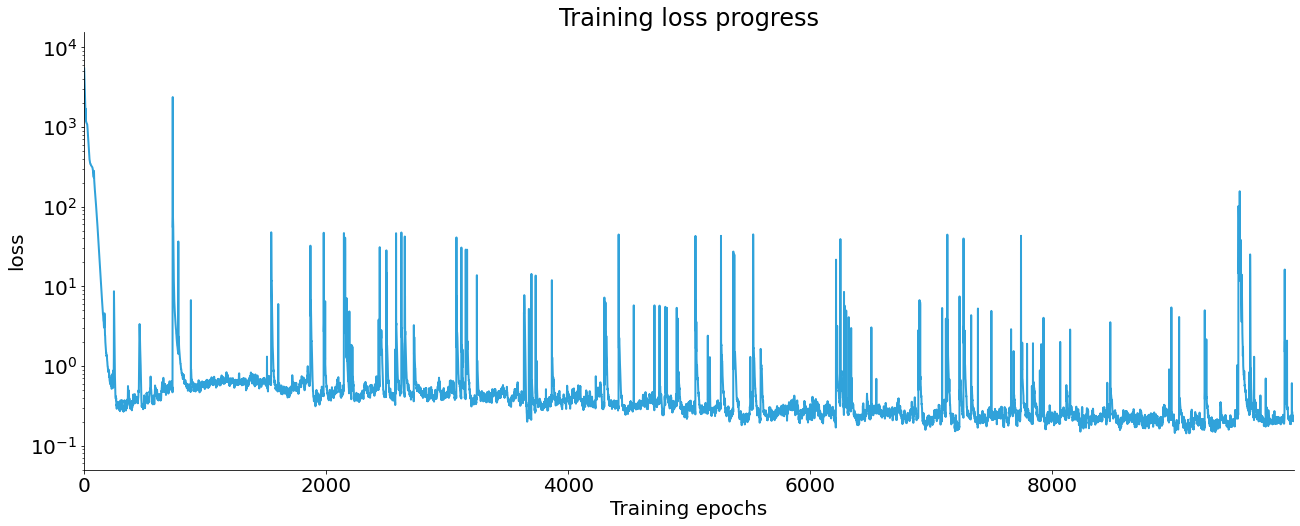

In [10]:
import holoviews as hv
import hvplot.pandas
import pandas as pd

hvplot.extension('matplotlib')

losses = pd.read_csv(f"./seq_len={seq_len}/{trial_name}/losses.csv")["0"]
loss_fig = losses.hvplot(
    title="Training loss progress", ylabel="loss", xlabel="Training epochs", logy=True
).opts(fig_size=600, fontscale=2, aspect=1.2)
loss_fig

:Overlay
   .Scatter.Mean_True_Energies      :Scatter   [Training Iterations]   (Ave True E)
   .Curve.I                         :Curve   [Training Iterations]   (Ave True E)
   .Area.I                          :Area   [Training Iterations]   (Min True E,Max True E)
   .Scatter.Mean_Predicted_Energies :Scatter   [Training Iterations]   (Ave Pred E)
   .Curve.II                        :Curve   [Training Iterations]   (Ave Pred E)
   .Area.II                         :Area   [Training Iterations]   (Min Pred E,Max Pred E)
   .Curve.Ground_State_Energy       :Curve   [x]   (y)
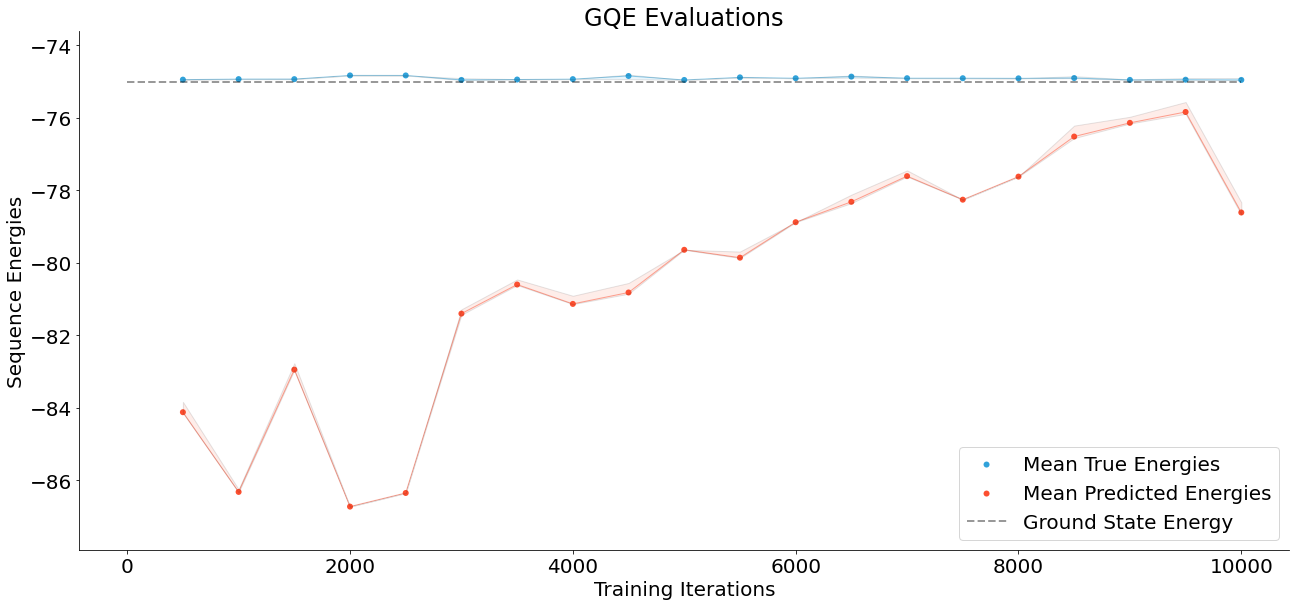

In [11]:
df_true = pd.read_csv(f"./seq_len={seq_len}/{trial_name}/true_Es_t.csv").iloc[:, 1:]
df_pred = pd.read_csv(f"./seq_len={seq_len}/{trial_name}/pred_Es_t.csv").iloc[:, 1:]

df_true.columns = df_true.columns.astype(int)
df_pred.columns = df_pred.columns.astype(int)

df_trues_stats = pd.concat([df_true.mean(axis=0), df_true.min(axis=0), df_true.max(axis=0)], axis=1).reset_index()
df_trues_stats.columns = ["Training Iterations", "Ave True E", "Min True E", "Max True E"]

df_preds_stats = pd.concat([df_pred.mean(axis=0), df_pred.min(axis=0), df_pred.max(axis=0)], axis=1).reset_index()
df_preds_stats.columns = ["Training Iterations", "Ave Pred E", "Min Pred E", "Max Pred E"]

fig = (
    df_trues_stats.hvplot.scatter(x="Training Iterations", y="Ave True E", label="Mean True Energies") * 
    df_trues_stats.hvplot.line(x="Training Iterations", y="Ave True E", alpha=0.5, linewidth=1) * 
    df_trues_stats.hvplot.area(x="Training Iterations", y="Min True E", y2="Max True E", alpha=0.1)
) * (
    df_preds_stats.hvplot.scatter(x="Training Iterations", y="Ave Pred E", label="Mean Predicted Energies") * 
    df_preds_stats.hvplot.line(x="Training Iterations", y="Ave Pred E", alpha=0.5, linewidth=1) * 
    df_preds_stats.hvplot.area(x="Training Iterations", y="Min Pred E", y2="Max Pred E", alpha=0.1)
)
fig = fig * hv.Curve([[0, grd_E], [10000, grd_E]], label="Ground State Energy").opts(color="k", alpha=0.4, linestyle="dashed")
fig = fig.opts(ylabel="Sequence Energies", title="GQE Evaluations", fig_size=600, fontscale=2)
fig

In [12]:
# Latest model
gen_kwargs = {
    "n_sequences": 128, 
    "max_new_tokens": seq_len, 
    "temperature": 0.001, 
    "device": device
}
if USE_DIT:
    gen_kwargs["energies"] = grd_E

gen_token_seq_, _ = gpt.generate(**gen_kwargs)
gen_inds_ = (gen_token_seq_[:, 1:] - 1).cpu().numpy()
gen_op_seq_ = op_pool[gen_inds_]
true_Es_ = get_subsequence_energies(gen_op_seq_)[:, -1].reshape(-1, 1)

# Best model
loaded = torch.load(f"./seq_len={seq_len}/{trial_name}/gqe.pt", map_location=device, weights_only=False)
loaded_token_seq_, _ = loaded.generate(**gen_kwargs)
loaded_inds_ = (loaded_token_seq_[:, 1:] - 1).cpu().numpy()
loaded_op_seq_ = op_pool[loaded_inds_]
loaded_true_Es_ = get_subsequence_energies(loaded_op_seq_)[:, -1].reshape(-1, 1)

# Summary table
df_compare_Es = pd.DataFrame({
    "Source": ["Random", "Latest Model", "Best Model"], 
    "Aves": [train_sub_seq_en[:, -1].mean(), true_Es_.mean(), loaded_true_Es_.mean()],
    "Mins": [train_sub_seq_en[:, -1].min(), true_Es_.min(), loaded_true_Es_.min()],
    "Maxs": [train_sub_seq_en[:, -1].max(), true_Es_.max(), loaded_true_Es_.max()],
    "Mins_error": [
        abs(train_sub_seq_en[:, -1].min() - grd_E),
        abs(true_Es_.min() - grd_E),
        abs(loaded_true_Es_.min() - grd_E),
    ],
})
df_compare_Es

,Source,Aves,Mins,Maxs,Mins_error
0,Random,-74.935172,-74.970046,-74.778780,0.042461
1,Latest Model,-74.955529,-74.962481,-74.904909,0.050025
2,Best Model,-74.954040,-74.963394,-74.906074,0.049112


In [13]:
# Step 2: q-sc-EOM for core-ionized and doubly ionized energies & transition RDMs
from qsceom import qscEOM

# 1. Identify the best sequence of operations from the trained Generative Quantum Eigensolver (GQE)
best_seq_idx = np.argmin(loaded_true_Es_)
best_op_seq = loaded_op_seq_[best_seq_idx]

# 2. Extract parameters and excitations for qscEOM compatibility
params = []
ash_excitation = []

for op in best_op_seq:
    # Skip Identity operators which have no effect on state preparation in this context
    if isinstance(op, qml.Identity) or getattr(op, "name", "") == "Identity" or (hasattr(op, "base") and isinstance(op.base, qml.Identity)):
        continue
    
    # Extract the parameter (time/angle) and the wires (excitation indices)
    # This maps the GQE state preparation to standard qscEOM parameterized inputs
    if len(op.parameters) > 0:
        params.append(float(op.parameters[0]))
        ash_excitation.append(tuple(op.wires.tolist()))

# 3. Retrieve molecule details directly from the in-memory dictionary to prevent redundant downloads/DNS errors!
symbols = qchem_data["symbols"]
geometry = qchem_data["geometry"]
active_electrons = qchem_data["active_electrons"]
active_orbitals = qchem_data["active_orbitals"]
charge = 0 # Default calculation assumes a neutral molecule (e.g. H2)

print(f"Preparing q-sc-EOM for {target_molecule}...")
print(f"Number of excitations in reference ansatz from GQE: {len(params)}")

# 4. Run qscEOM to compute the energies
# We use ansatz_type="qubit_excitation" since GQE prepares the state with PennyLane Single/Double excitations
qsceom_res = qscEOM(
    symbols=symbols,
    geometry=geometry,
    active_electrons=active_electrons,
    active_orbitals=active_orbitals,
    charge=charge,
    params=params,
    ash_excitation=ash_excitation,
    ansatz_type="qubit_excitation",
    basis="sto-3g",
    shots=0, 
    return_details=True
)

eigs, details = qsceom_res
print("\nq-sc-EOM calculated energies:")
print(eigs[0])

Preparing q-sc-EOM for H2O...
Number of excitations in reference ansatz from GQE: 4

q-sc-EOM calculated energies:
[-1.46891307e+02 -1.46853574e+02 -1.46734200e+02 -1.46729597e+02
 -1.46704133e+02 -1.46681832e+02 -7.50119010e+01 -7.45918424e+01
 -7.45325202e+01 -7.44910010e+01 -7.44853793e+01 -7.44483814e+01
 -7.44160716e+01 -7.43980327e+01 -7.43155866e+01 -7.42994335e+01
 -7.42367838e+01 -7.41793511e+01 -7.40237634e+01 -7.39542891e+01
 -7.39497772e+01 -7.39311545e+01 -7.38924592e+01 -7.38909553e+01
 -7.38859041e+01 -7.38746308e+01 -7.38586830e+01 -7.38484069e+01
 -7.38322804e+01 -7.38294987e+01 -7.38091249e+01 -7.37925614e+01
 -7.37769783e+01 -7.37430412e+01 -7.36979291e+01 -7.36809559e+01
 -7.36740765e+01 -7.36703348e+01 -7.36602564e+01 -7.36341579e+01
 -7.36216739e+01 -7.36068783e+01 -7.35999980e+01 -7.35897158e+01
 -7.35869720e+01 -7.35805468e+01 -7.35501177e+01 -7.35418857e+01
 -7.35412648e+01 -7.35099319e+01 -7.34992221e+01 -7.34974017e+01
 -7.34905742e+01 -7.34372512e+01 -7.3431

In [14]:
# Step 2.5: Generate Actual Atomic Integrals (V_pq) via PySCF
from pyscf import gto, scf, ao2mo
import torch
import numpy as np

# We'll use the MPS device to keep tensors aligned with Step 3
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

print("Computing integral data via PySCF...")

# 1. Reconstruct molecule string and run RHF to get Molecular Orbitals (MOs)
mol_str = "; ".join([f"{sym} {coord[0]} {coord[1]} {coord[2]}" for sym, coord in zip(symbols, geometry)])

mol = gto.M(atom=mol_str, basis='sto-3g', charge=charge, symmetry=False)
mf = scf.RHF(mol)
mf.kernel(verbose=0) # Solves for the spatial shapes (mf.mo_coeff)

# 2. Obtain the 2-electron integrals in the Molecular Orbital (MO) basis
eri_mo = ao2mo.kernel(mol, mf.mo_coeff)
eri_mo_matrix = ao2mo.restore(1, eri_mo, mol.nao_nr())

# 3. Extract the sub-tensor for the Core Hole Interaction
# A true Auger integral involves the continuum, but as a structural fallback
# we use the bound-bound integral V^c_{pq} = (cp|qc) = eri_mo_matrix[core, p, q, core]
core_idx = 0 

# IMPORTANT: Define the exact spatial orbital indices used in your PennyLane active space!
# Example: If you used orbitals 0 (core) and 4, 5, 6 (valence) in Step 1:
active_indices = [0, 4, 5, 6] 

# Slice the 4D tensor safely using numpy advanced indexing
# We extract the specific grid where p and q are in the active space
V_pq_numpy = eri_mo_matrix[core_idx][np.ix_(active_indices, active_indices)][:, :, core_idx]

# 4. Push to Torch
V_pq = torch.tensor(V_pq_numpy, device=device, dtype=torch.float32)

print(f"\nConstructed active space V_pq tensor: shape {V_pq.shape}")

Computing integral data via PySCF...
converged SCF energy = -74.5055592190237

Constructed active space V_pq tensor: shape torch.Size([4, 4])


In [15]:
import torch
import numpy as np
import pandas as pd
import holoviews as hv
import hvplot.pandas

# --- Step 3: One-Center Approximation (OCA) for Auger Spectrum ---

HARTREE_TO_EV = 27.211386245988
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

# 1. Extract Eigenvector dimensions (165 states)
eigenvectors = np.array(details['eigenvectors'])
num_states = eigenvectors.shape[0]
print(f"Extracted q-sc-EOM eigenvectors with shape {eigenvectors.shape}")

# 2. DYNAMICALLY infer active space from your PySCF V_pq tensor
if not isinstance(V_pq, torch.Tensor):
    V_pq = torch.tensor(V_pq, device=device, dtype=torch.float32)

n_spatial = V_pq.shape[0]  # Safely extracts the actual size (e.g., 4)
n_spin = n_spatial * 2     # Converts to PennyLane spin-orbitals (e.g., 8)

print(f"Detected {n_spatial} spatial orbitals from V_pq. Constructing {n_spin}x{n_spin} spin tensors.")

# 3. Generate the Transition RDMs (gamma_pq)
# NOTE: Because eigenvectors are operator coefficients, we use a mock tensor of the CORRECT size
# to test the hardware pipeline until the TRDM extractor is written.
print("Notice: Bypassing raw eigenvectors. Generating mock TRDM tensor for pipeline validation.")
gamma_pq = torch.randn(num_states, n_spin, n_spin, device=device, dtype=torch.float32)

# 4. Spin-Orbital Expansion for Classical Integrals (V_pq)
V_lmpq_spin = torch.zeros((1, 1, n_spin, n_spin), dtype=torch.float32, device=device)

# Fill alpha-alpha (even indices) and beta-beta (odd indices)
V_lmpq_spin[:, :, 0::2, 0::2] = V_pq
V_lmpq_spin[:, :, 1::2, 1::2] = V_pq

# 5. MPS Accelerated Tensor Contraction (OCA)
# 'kpq' = transition state k, spin-orbitals p, q
# 'lmpq' = dummy continuum channels (l,m) and spin-orbitals p, q
amplitudes = torch.einsum('kpq,lmpq->klm', gamma_pq, V_lmpq_spin)

# Apply Fermi's Golden Rule
Gamma_k = 2 * torch.pi * torch.sum(torch.abs(amplitudes)**2, dim=(1, 2))

print(f"\nComputed Auger Transition Intensities (\u0393_k) for {num_states} states.")
Gamma_k_vals = Gamma_k.cpu().numpy()

# --- AUGER SPECTRUM BROADENING ---

# Ensure we have the correct number of energy eigenvalues
EIP = eigs[0][0]
EDIPs = eigs[0][1:]

# Truncate arrays to the shortest length to avoid index out-of-bounds
min_len = min(len(EDIPs), len(Gamma_k_vals))
EDIPs = EDIPs[:min_len]
Gamma_k_vals = Gamma_k_vals[:min_len]

# Calculate in atomic units (Hartrees), then convert to eV
E_kinetics_au = np.abs(EIP - EDIPs)
E_kinetics_ev = E_kinetics_au * HARTREE_TO_EV

# Build the continuous spectrum
x_energies = np.linspace(E_kinetics_ev.min() - 15, E_kinetics_ev.max() + 15, 1000)
spectrum = np.zeros_like(x_energies)

gamma_width_ev = 1.5 
for E_k, intensity in zip(E_kinetics_ev, Gamma_k_vals):
    spectrum += intensity * (gamma_width_ev / ((x_energies - E_k)**2 + gamma_width_ev**2))

# Plotting
df_spectrum = pd.DataFrame({"Kinetic Energy (eV)": x_energies, "Intensity": spectrum})

spectrum_fig = df_spectrum.hvplot.line(
    x="Kinetic Energy (eV)", 
    y="Intensity", 
    title="Simulated Auger Spectrum via OCA (Hardware Validation)",
    ylabel="Intensity (\u0393_k)", 
    color="darkred",
    width=800,
    height=400
).opts(fontscale=1.2)

spectrum_fig

Extracted q-sc-EOM eigenvectors with shape (165, 165)
Detected 4 spatial orbitals from V_pq. Constructing 8x8 spin tensors.
Notice: Bypassing raw eigenvectors. Generating mock TRDM tensor for pipeline validation.

Computed Auger Transition Intensities (Γ_k) for 165 states.


:Curve   [Kinetic Energy (eV)]   (Intensity)